<a href="https://colab.research.google.com/github/Adityas221b/Pytorch/blob/main/Simple_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [22]:
##create a motto class that inherits nn.module here

In [23]:
# class Model(nn.Module):
#   # #input layer(4 features of flower here )-->
#   # Hidden layer1 (some no of neurons here)---->
#   # goes to H2---->H3 SAME WAY--->
#   # OUTPUT (3 CLASSES OR IRIS FLOWER HERE ) in_features=4 mentioned in dataset

#   def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
#    super().__init__()  #instantiate our nn.module
#    self.fc1 =nn.Linear(in_features,h1)##fc1 is fully connected layer
#    self.fc2 =nn.Linear(h1,h2)
#    self.out=nn.Linear(h2,out_features)

# ##need some function that move everythingg forward here
#   def forward(self,x):
#    x=F.relu(self.fc1(x))           #relu here stands for rectified linear unit  do something if less than 0 consider it 0 here
#    x=F.relu(self.fc2(x))
#    x=self.out(x)
#    return x


import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    # ⚠️ FIXED: Indented to be INSIDE the class
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x


In [24]:
model=Model()

In [25]:
## we need to turn it on now but beforre that we need to create manual seed here

In [26]:
#pick a manual seed for randomization
torch.manual_seed(41)
#create instance for our model here
model=Model()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
url='https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'   #to load our data here
my_df= pd.read_csv(url)       #df is dataframe here

In [29]:
my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [30]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [31]:
##cant use words in machine learnig here
#CONVERT LAST COLOUMN FROM STRING INTO INTEGERS
my_df['variety'] = my_df['variety'].replace('Setosa',0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor',1.0)
my_df['variety'] = my_df['variety'].replace('Virginica',2.0)
my_df

/tmp/ipykernel_2558/2084468188.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica',2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [32]:
#Train test and split things here     Set X,y
X= my_df.drop('variety',axis=1)
y=my_df['variety']
X

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [33]:
##CONVERT THIS TO NUMPY ARRAYS
X=X.values
y=y.values

In [34]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
##train test split here
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=41)

In [37]:
#convert  x  to float tensors
X_train =torch.FloatTensor(X_train)
X_test =torch.FloatTensor(X_test)
y_train =torch.FloatTensor(y_train)
y_test =torch.FloatTensor(y_test)

In [38]:
model = Model()  # Define model FIRST
#chosse adam optimizer  ,lr is learning rate here (if error rates  doesnt go doen here after a bunch of iterations(epochs) )
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # THEN attach it
#set the creiteria to set how ffar iss prediction from actual labelling here
criterion = nn.CrossEntropyLoss()

Epoch: 0 | Loss: 1.1145
Epoch: 10 | Loss: 0.8764
Epoch: 20 | Loss: 0.5598
Epoch: 30 | Loss: 0.4081
Epoch: 40 | Loss: 0.3237
Epoch: 50 | Loss: 0.2101
Epoch: 60 | Loss: 0.1134
Epoch: 70 | Loss: 0.0681
Epoch: 80 | Loss: 0.0487
Epoch: 90 | Loss: 0.0396
Epoch: 100 | Loss: 0.0344
Epoch: 110 | Loss: 0.0310
Epoch: 120 | Loss: 0.0284
Epoch: 130 | Loss: 0.0264
Epoch: 140 | Loss: 0.0248
Epoch: 150 | Loss: 0.0234
Epoch: 160 | Loss: 0.0221
Epoch: 170 | Loss: 0.0211
Epoch: 180 | Loss: 0.0201
Epoch: 190 | Loss: 0.0192
Epoch: 200 | Loss: 0.0184
Epoch: 210 | Loss: 0.0176
Epoch: 220 | Loss: 0.0181
Epoch: 230 | Loss: 0.0167
Epoch: 240 | Loss: 0.0159
Epoch: 250 | Loss: 0.0153
Epoch: 260 | Loss: 0.0147
Epoch: 270 | Loss: 0.0142
Epoch: 280 | Loss: 0.0137
Epoch: 290 | Loss: 0.0133


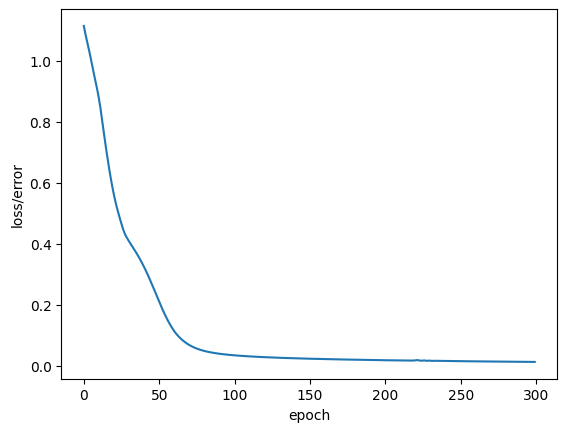

In [42]:
# #train our model
y_train = y_train.long()
y_test = y_test.long()
# #epoch (run data through our neural netork here )
# epochs =100
# losses =[]
# for i in range(epochs):
#   #go forward get a prediction here
#   y_pred =model.forward(X_train) #get  predictive result

#   #measure the loss
#   loss =criteria(y_pred,y_train)  #predict values vs y_train

#   #kepp track of all the losses here
#   losses.append(loss.detach().numpy)

#   #print every 10 epoch here
#   if i%10 ==0:
#    print(f'Epoch:{i} and loss {loss}')

#   #do some backpropogation here :take the error rates of forward and feed it back thru the network to finetune the weights
#   optimizer.zero_grad()
#   loss.backward()
#   optimizer.step()


epochs = 300
losses = []

for i in range(epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    # FIX: Add () or use .item()
    losses.append(loss.item())  # ✅ This saves the actual number

    if i % 10 == 0:
        print(f'Epoch: {i} | Loss: {loss.item():.4f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Now this will work:
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('epoch')
plt.show()


In [43]:
#evaluate this on test dataset here
with torch.no_grad():  #turn off backpropogation
 y_eval =model.forward(X_test)#X_test  are features from our test here y_eval will be  predictions here
 loss=criterion(y_eval,y_test)
 print(f'performance on test set {loss}')


performance on test set 0.21369194984436035


In [44]:
loss

tensor(0.2137)

In [45]:
correct=0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val=model.forward(data)

#twll us wht  is the flower class our network thisnk its
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]}\t {y_val.argmax().item()}')

    #correct or not here
    if y_val.argmax().item() ==y_test[i]:
      correct+=1
print(f'\n{correct} out of {len(y_test)} = {100*correct/len(y_test):.2f}% correct')


1.) tensor([-9.1920,  2.9356,  9.4080]) 	 2	 2
2.) tensor([-14.2638,  -0.3064,  18.8471]) 	 2	 2
3.) tensor([-14.9659,   0.6574,  18.8091]) 	 2	 2
4.) tensor([-3.6949,  7.4567, -2.3868]) 	 1	 1
5.) tensor([-12.0463,   1.9911,  13.8469]) 	 2	 2
6.) tensor([-2.2899,  7.5298, -5.2873]) 	 1	 1
7.) tensor([-8.4920,  4.0655,  7.3772]) 	 2	 2
8.) tensor([-3.6413,  7.5796, -2.6433]) 	 1	 1
9.) tensor([-10.2392,   3.0903,  10.5118]) 	 2	 2
10.) tensor([-15.1878,  -0.3525,  20.0579]) 	 2	 2
11.) tensor([-7.8750,  4.5470,  6.1610]) 	 2	 2
12.) tensor([ 11.3696,   1.9552, -19.4977]) 	 0	 0
13.) tensor([ 10.3848,   1.7417, -17.7132]) 	 0	 0
14.) tensor([-0.7153,  6.2784, -6.2683]) 	 1	 1
15.) tensor([  9.4418,   2.7587, -17.6266]) 	 0	 0
16.) tensor([-6.9081,  5.4767,  4.1427]) 	 2	 1
17.) tensor([ 10.3799,   2.0394, -18.1103]) 	 0	 0
18.) tensor([-8.7515,  3.6137,  8.2208]) 	 1	 2
19.) tensor([ 11.9844,   1.6654, -20.0136]) 	 0	 0
20.) tensor([  8.9885,   2.0637, -16.0710]) 	 0	 0
21.) tensor([-1.

In [55]:
##new data and new prediction heree
new_iris=torch.tensor([4.7,3.2,1.3,0.2])
new_iris




tensor([4.7000, 3.2000, 1.3000, 0.2000])

In [56]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 10.9754,   1.7799, -18.6569])


In [63]:
new_data=torch.tensor([5.9,3.0,5.1,1.8])
with torch.no_grad():
 print(model(new_data))

tensor([-9.4803,  3.0919,  9.6052])


In [64]:
##save and load our NN model here
torch.save(model.state_dict(),'my_awesome_iris_NN.pt')

In [65]:
#load saved model
new_model = Model()
new_model.load_state_dict(torch.load('my_awesome_iris_NN.pt'))

<All keys matched successfully>

In [67]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)